In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df_M_convo_topic = pd.read_csv("M/data_topic/final_topic_convo_M.csv")

In [3]:
bert_dist_M = (
    df_M_convo_topic.groupby(["topic_label", "bert_majority_label"])
      .size()
      .unstack()
)

compound_dist_M = (
    df_M_convo_topic.groupby(["topic_label", "compound_utt_label"])
      .size()
      .unstack()
)

In [4]:
bert_pct_M = bert_dist_M.div(bert_dist_M.sum(axis=1), axis=0)
compound_pct_M = compound_dist_M.div(compound_dist_M.sum(axis=1), axis=0)

In [10]:
summary_M = pd.concat(
    {
        # "bert_counts": bert_dist_E,
        "bert_pct": round(bert_pct_M * 100, 2),
        # "compound_counts": compound_dist_E,
        # "compound_pct": round(compound_pct_T * 100, 2)
    },
    axis=1
)

In [11]:
summary_M

bert_pct                 
bert_majority_label Negative Neutral Positive
topic_label                                  
Customization          22.94   53.05    24.01
Gameplay               29.09   50.60    20.31
Hardware               27.49   56.74    15.77
Other                  27.43   53.70    18.88
Problems               63.12   31.86     5.03
Social                 37.04   45.10    17.86

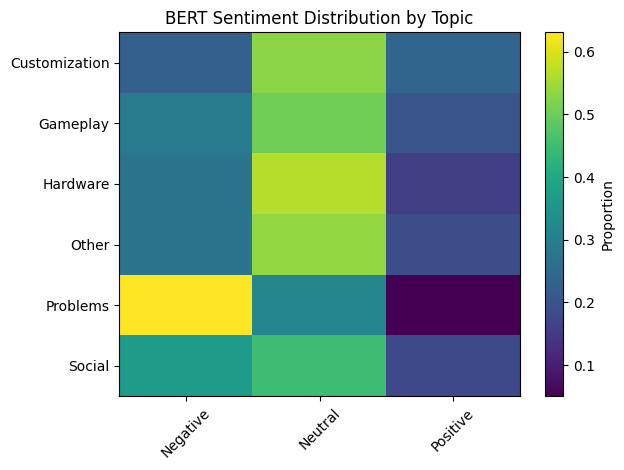

In [ ]:
plt.imshow(bert_pct_M, aspect='auto')

plt.xticks(range(len(bert_pct_M.columns)), bert_pct_M.columns, rotation=45)
plt.yticks(range(len(bert_pct_M.index)), bert_pct_M.index)

plt.title("roBERTa Sentiment Distribution by Topic - M Rated Bucket")
plt.colorbar(label="Proportion")

plt.tight_layout()
plt.show()